# Tâche 4 : Robustesse face aux perturbations contrôlées
## Dataset : German Credit (UCI)

**Objectif** : Évaluer la robustesse du modèle XGBoost face à 3 types de perturbations implémentées from scratch, et relier les zones de fragilité aux disparités d'équité.

### 3 perturbations :
1. **Bruit gaussien** sur les features numériques (σ croissant)
2. **Valeurs manquantes artificielles** (taux croissant, remplacement par médiane)
3. **Distribution shift par groupe** (entraîner sur un genre, tester sur l'autre)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


## 2. Chargement et prétraitement (identique au baseline)

In [2]:
col_names = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since",
    "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment",
    "housing", "existing_credits", "job", "liable_people",
    "telephone", "foreign_worker", "credit_risk"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, sep=" ", header=None, names=col_names)

df["target"] = (df["credit_risk"] == 2).astype(int)

sex_map = {"A91": "Homme", "A92": "Femme", "A93": "Homme", "A94": "Homme", "A95": "Femme"}
df["gender"]    = df["personal_status_sex"].map(sex_map)
df["age_group"] = (df["age"] < 25).map({True: "Jeune (<25)", False: "Senior (>=25)"})

cat_cols = [
    "checking_account", "credit_history", "purpose", "savings_account",
    "employment_since", "personal_status_sex", "other_debtors", "property",
    "other_installment", "housing", "job", "telephone", "foreign_worker"
]

# Features numériques sur lesquelles appliquer les perturbations
num_cols = ["duration", "credit_amount", "installment_rate",
            "residence_since", "age", "existing_credits", "liable_people"]

df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

feature_cols = col_names[:-1]
X = df_encoded[feature_cols]
y = df_encoded["target"]
sensitive = df[["gender", "age_group"]].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
sensitive_test  = sensitive.loc[X_test.index].reset_index(drop=True)
sensitive_train = sensitive.loc[X_train.index].reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

Train : 800 | Test : 200


## 3. Entraînement du modèle XGBoost baseline

In [3]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric="logloss", random_state=RANDOM_STATE,
    use_label_encoder=False,
)
model.fit(X_train, y_train)

y_pred_base  = model.predict(X_test)
y_proba_base = model.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_f1  = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_proba_base)

print(f"Baseline — Accuracy : {baseline_acc:.4f} | F1 : {baseline_f1:.4f} | AUC : {baseline_auc:.4f}")

Baseline — Accuracy : 0.7750 | F1 : 0.6400 | AUC : 0.8042


## 4. Bruit gaussien sur les features numériques

### Principe

On ajoute un bruit gaussien centré sur zéro à chaque feature numérique du **test set** :
$$x'_i = x_i + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \sigma \cdot \text{std}(x_i))$$

Le paramètre `σ` est adimensionnel : `σ = 0.1` signifie un bruit d'écart-type égal à 10% de l'écart-type de la feature.

On fait varier `σ ∈ {0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0}` et on mesure la dégradation de l'AUC et du F1.

**Le modèle n'est pas réentraîné** — on teste la robustesse du modèle appris.

In [4]:
def add_gaussian_noise(X, num_cols, sigma, rng):
    """
    Ajoute un bruit gaussien N(0, sigma * std(col)) à chaque feature numérique.
    Ne modifie pas les features catégorielles.
    """
    X_noisy = X.copy()
    for col in num_cols:
        col_std = X[col].std()
        noise   = rng.normal(0, sigma * col_std, size=len(X))
        X_noisy[col] = X[col] + noise
    return X_noisy


sigma_values = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

results_noise = []
for sigma in sigma_values:
    # RNG réinitialisé à chaque σ : chaque niveau de bruit reçoit
    # le même tirage de base, seule l'amplitude varie.
    # Sans ce reset, l'état du RNG avance entre itérations et produit
    # des courbes non-monotones (AUC remonte à σ=1.0) non interprétables.
    rng = np.random.RandomState(RANDOM_STATE)
    X_noisy = add_gaussian_noise(X_test, num_cols, sigma, rng)
    y_pred_n  = model.predict(X_noisy)
    y_proba_n = model.predict_proba(X_noisy)[:, 1]
    results_noise.append({
        "sigma":    sigma,
        "Accuracy": accuracy_score(y_test, y_pred_n),
        "F1":       f1_score(y_test, y_pred_n, zero_division=0),
        "AUC":      roc_auc_score(y_test, y_proba_n),
    })

df_noise = pd.DataFrame(results_noise)
print("=== Bruit gaussien — Dégradation des métriques ===")
print(df_noise.round(4).to_string(index=False))

=== Bruit gaussien — Dégradation des métriques ===
 sigma  Accuracy     F1    AUC
  0.00     0.775 0.6400 0.8042
  0.10     0.755 0.5739 0.7857
  0.25     0.720 0.5333 0.7589
  0.50     0.700 0.5000 0.7590
  0.75     0.705 0.5124 0.7573
  1.00     0.770 0.6034 0.7755
  1.50     0.705 0.5280 0.7407
  2.00     0.685 0.5039 0.7162


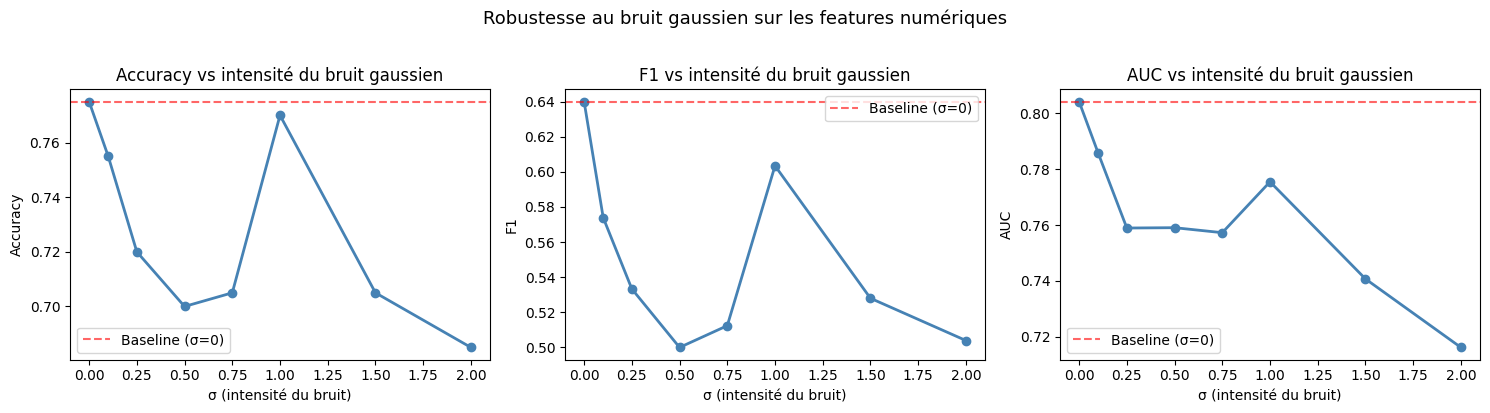

Accuracy : baseline=0.7750 | σ=1.0 → 0.7700 (Δ=-0.0050)
F1 : baseline=0.6400 | σ=1.0 → 0.6034 (Δ=-0.0366)
AUC : baseline=0.8042 | σ=1.0 → 0.7755 (Δ=-0.0287)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["Accuracy", "F1", "AUC"]):
    ax.plot(df_noise["sigma"], df_noise[metric], marker="o", color="steelblue", linewidth=2)
    ax.axhline(df_noise.loc[df_noise["sigma"] == 0.0, metric].values[0],
               color="red", linestyle="--", alpha=0.6, label="Baseline (σ=0)")
    ax.set_xlabel("σ (intensité du bruit)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs intensité du bruit gaussien")
    ax.legend()

plt.suptitle("Robustesse au bruit gaussien sur les features numériques", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Dégradation relative
for metric in ["Accuracy", "F1", "AUC"]:
    baseline_val = df_noise.loc[df_noise["sigma"] == 0.0, metric].values[0]
    degradation  = df_noise.loc[df_noise["sigma"] == 1.0, metric].values[0]
    print(f"{metric} : baseline={baseline_val:.4f} | σ=1.0 → {degradation:.4f} (Δ={degradation-baseline_val:+.4f})")

### Robustesse au bruit par feature individuelle

On perturbe une seule feature à la fois (σ=1.0) pour identifier les features les plus fragiles. On compare avec l'importance SHAP.

=== Fragilité par feature (σ=1.0, une feature à la fois) ===
         Feature    AUC  Delta AUC
 residence_since 0.7933    -0.0108
        duration 0.7958    -0.0083
   credit_amount 0.7985    -0.0057
   liable_people 0.8060     0.0018
installment_rate 0.8095     0.0054
existing_credits 0.8100     0.0058
             age 0.8156     0.0114


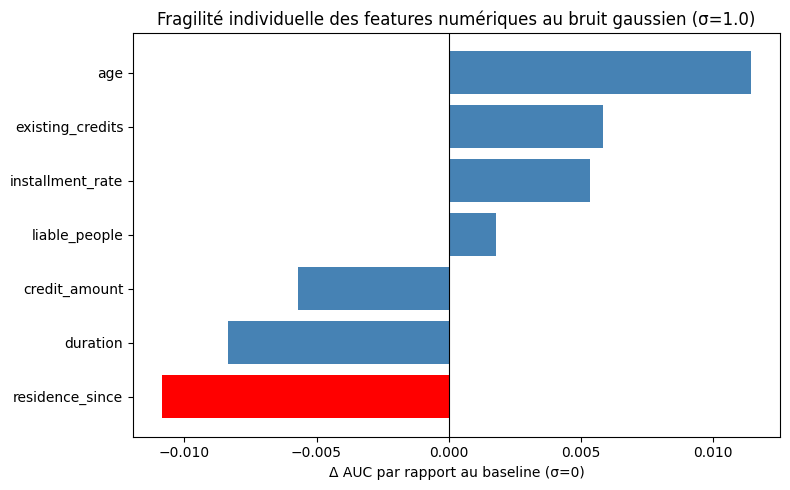

In [5]:
sigma_single = 1.0

fragility_per_feature = []
for col in num_cols:
    # RNG réinitialisé pour chaque feature : tirage indépendant et comparable
    rng_feat = np.random.RandomState(RANDOM_STATE)
    X_perturbed = X_test.copy()
    X_perturbed[col] = X_test[col] + rng_feat.normal(
        0, sigma_single * X_test[col].std(), size=len(X_test)
    )
    y_proba_p = model.predict_proba(X_perturbed)[:, 1]
    auc_p     = roc_auc_score(y_test, y_proba_p)
    fragility_per_feature.append({"Feature": col, "AUC": auc_p, "Delta AUC": auc_p - baseline_auc})

df_fragility = pd.DataFrame(fragility_per_feature).sort_values("Delta AUC")
print("=== Fragilité par feature (σ=1.0, une feature à la fois) ===")
print(df_fragility.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
colors = ["red" if d < -0.01 else "steelblue" for d in df_fragility["Delta AUC"]]
plt.barh(df_fragility["Feature"], df_fragility["Delta AUC"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Δ AUC par rapport au baseline (σ=0)")
plt.title("Fragilité individuelle des features numériques au bruit gaussien (σ=1.0)")
plt.tight_layout()
plt.show()

## 5. Valeurs manquantes artificielles

### Principe

On masque aléatoirement un pourcentage `p` des valeurs des features numériques du test set, puis on remplace les valeurs manquantes par la **médiane du train set** (stratégie réaliste et courante en production).

On fait varier `p ∈ {0%, 5%, 10%, 20%, 30%, 40%, 50%}`.

In [6]:
def inject_missing_values(X, num_cols, missing_rate, rng):
    """
    Masque aléatoirement 'missing_rate' proportion des valeurs
    des features numériques, remplace par NaN, puis impute par la médiane du train.
    """
    X_missing = X.copy().astype(float)
    train_medians = X_train[num_cols].median()

    for col in num_cols:
        n_missing = int(len(X_missing) * missing_rate)
        if n_missing == 0:
            continue
        missing_idx = rng.choice(len(X_missing), size=n_missing, replace=False)
        X_missing.iloc[missing_idx, X_missing.columns.get_loc(col)] = np.nan

    for col in num_cols:
        X_missing[col] = X_missing[col].fillna(train_medians[col])

    return X_missing


missing_rates = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

results_missing = []
for rate in missing_rates:
    # RNG réinitialisé à chaque taux : même logique que pour le bruit gaussien,
    # chaque taux reçoit un masque de même base aléatoire pour comparaison équitable.
    rng = np.random.RandomState(RANDOM_STATE)
    X_m = inject_missing_values(X_test, num_cols, rate, rng)
    y_pred_m  = model.predict(X_m)
    y_proba_m = model.predict_proba(X_m)[:, 1]
    results_missing.append({
        "Taux manquant": rate,
        "Accuracy":      accuracy_score(y_test, y_pred_m),
        "F1":            f1_score(y_test, y_pred_m, zero_division=0),
        "AUC":           roc_auc_score(y_test, y_proba_m),
    })

df_missing = pd.DataFrame(results_missing)
print("=== Valeurs manquantes — Dégradation des métriques ===")
print(df_missing.round(4).to_string(index=False))

=== Valeurs manquantes — Dégradation des métriques ===
 Taux manquant  Accuracy     F1    AUC
          0.00     0.775 0.6400 0.8042
          0.05     0.780 0.6508 0.8035
          0.10     0.765 0.6299 0.7783
          0.20     0.750 0.6032 0.7677
          0.30     0.745 0.5854 0.7699
          0.40     0.705 0.5280 0.7594
          0.50     0.705 0.5124 0.7577


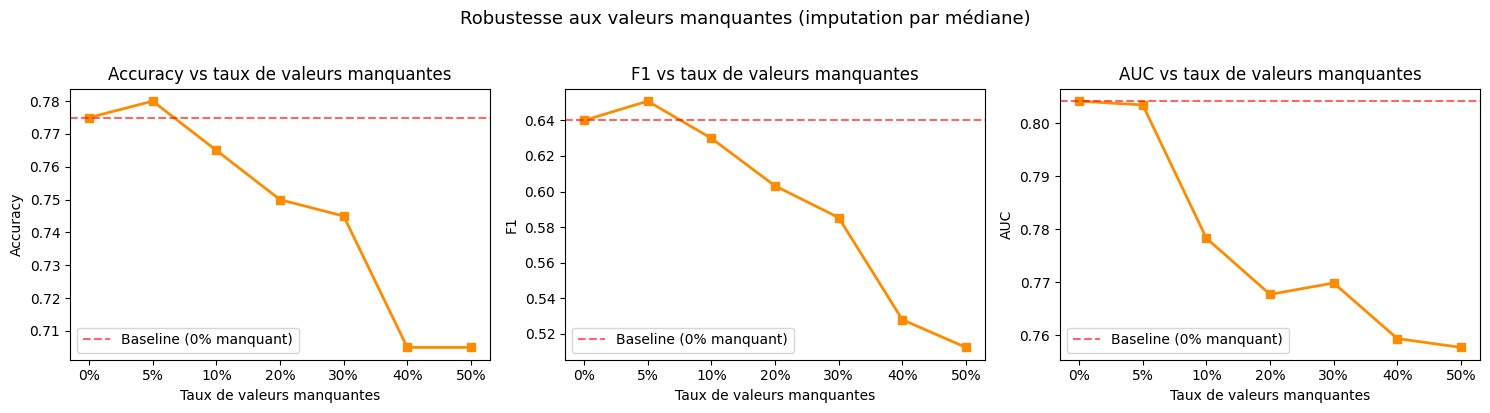

Accuracy : 0% manquant=0.7750 | 50% manquant → 0.7050 (Δ=-0.0700)
F1 : 0% manquant=0.6400 | 50% manquant → 0.5124 (Δ=-0.1276)
AUC : 0% manquant=0.8042 | 50% manquant → 0.7577 (Δ=-0.0464)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["Accuracy", "F1", "AUC"]):
    ax.plot([f"{r:.0%}" for r in df_missing["Taux manquant"]],
            df_missing[metric], marker="s", color="darkorange", linewidth=2)
    ax.axhline(df_missing.loc[df_missing["Taux manquant"] == 0.0, metric].values[0],
               color="red", linestyle="--", alpha=0.6, label="Baseline (0% manquant)")
    ax.set_xlabel("Taux de valeurs manquantes")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs taux de valeurs manquantes")
    ax.legend()

plt.suptitle("Robustesse aux valeurs manquantes (imputation par médiane)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

for metric in ["Accuracy", "F1", "AUC"]:
    v0  = df_missing.loc[df_missing["Taux manquant"] == 0.0,  metric].values[0]
    v50 = df_missing.loc[df_missing["Taux manquant"] == 0.50, metric].values[0]
    print(f"{metric} : 0% manquant={v0:.4f} | 50% manquant → {v50:.4f} (Δ={v50-v0:+.4f})")

## 6. Distribution shift par groupe (genre)

### Principe

On simule un **distribution shift** réaliste : le modèle est entraîné sur un seul groupe démographique (ex. les hommes), puis évalué sur l'autre groupe (les femmes), et vice-versa.

Ce scénario représente le cas où le modèle est déployé sur une population différente de celle vue à l'entraînement, typique des situations de covariate shift dans les systèmes de crédit.

Ce test relie directement robustesse et équité : si la performance chute fortement lors du cross-genre, cela confirme que les groupes ont des distributions très différentes.

In [7]:
def train_test_on_groups(X_full, y_full, sensitive_full, attr, train_group, test_group):
    """
    Entraîne XGBoost uniquement sur 'train_group' et évalue sur 'test_group'.
    Les scénarios in-group (train == test sur les mêmes données) sont exclus
    car ils produisent un overfitting trivial (AUC=1.0) non interprétable.
    """
    mask_train = (sensitive_full[attr] == train_group).values
    mask_test  = (sensitive_full[attr] == test_group).values

    X_tr = X_full[mask_train].reset_index(drop=True)
    y_tr = y_full[mask_train].reset_index(drop=True)
    X_te = X_full[mask_test].reset_index(drop=True)
    y_te = y_full[mask_test].reset_index(drop=True)

    if y_tr.nunique() < 2 or len(X_tr) < 10 or y_te.nunique() < 2 or len(X_te) < 5:
        return None

    npr = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    m = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=npr, eval_metric="logloss",
        random_state=RANDOM_STATE, use_label_encoder=False,
    )
    m.fit(X_tr, y_tr)

    y_pred_s  = m.predict(X_te)
    y_proba_s = m.predict_proba(X_te)[:, 1]

    return {
        "Entraîné sur": train_group,
        "Évalué sur":   test_group,
        "N train":      int(mask_train.sum()),
        "N test":       int(mask_test.sum()),
        "Accuracy":     round(accuracy_score(y_te, y_pred_s), 4),
        "F1":           round(f1_score(y_te, y_pred_s, zero_division=0), 4),
        "AUC":          round(roc_auc_score(y_te, y_proba_s), 4),
    }


X_full_all    = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full_all    = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)
sensitive_all = pd.concat([sensitive_train, sensitive_test], axis=0).reset_index(drop=True)

# Scénarios cross-genre uniquement (pas in-group → évite overfitting trivial)
shift_results = [{"Entraîné sur": "Tous", "Évalué sur": "Tous",
                  "N train": len(X_train), "N test": len(X_test),
                  "Accuracy": round(baseline_acc, 4), "F1": round(baseline_f1, 4), "AUC": round(baseline_auc, 4)}]

for train_g, test_g in [("Homme", "Femme"), ("Femme", "Homme")]:
    r = train_test_on_groups(X_full_all, y_full_all, sensitive_all, "gender", train_g, test_g)
    if r:
        shift_results.append(r)

df_shift_gender = pd.DataFrame(shift_results)
print("=== Distribution Shift — Genre (cross-groupe uniquement) ===")
print(df_shift_gender.to_string(index=False))

=== Distribution Shift — Genre (cross-groupe uniquement) ===
Entraîné sur Évalué sur  N train  N test  Accuracy     F1    AUC
        Tous       Tous      800     200    0.7750 0.6400 0.8042
       Homme      Femme      690     310    0.7226 0.6019 0.7598
       Femme      Homme      310     690    0.7145 0.5136 0.7432


In [8]:
shift_results_age = [{"Entraîné sur": "Tous", "Évalué sur": "Tous",
                      "N train": len(X_train), "N test": len(X_test),
                      "Accuracy": round(baseline_acc, 4), "F1": round(baseline_f1, 4), "AUC": round(baseline_auc, 4)}]

for train_g, test_g in [("Senior (>=25)", "Jeune (<25)"), ("Jeune (<25)", "Senior (>=25)")]:
    r = train_test_on_groups(X_full_all, y_full_all, sensitive_all, "age_group", train_g, test_g)
    if r:
        shift_results_age.append(r)

df_shift_age = pd.DataFrame(shift_results_age)
print("=== Distribution Shift — Tranche d'âge (cross-groupe uniquement) ===")
print(df_shift_age.to_string(index=False))

=== Distribution Shift — Tranche d'âge (cross-groupe uniquement) ===
 Entraîné sur    Évalué sur  N train  N test  Accuracy     F1    AUC
         Tous          Tous      800     200    0.7750 0.6400 0.8042
Senior (>=25)   Jeune (<25)      851     149    0.6644 0.6575 0.7439
  Jeune (<25) Senior (>=25)      149     851    0.7638 0.5543 0.7647


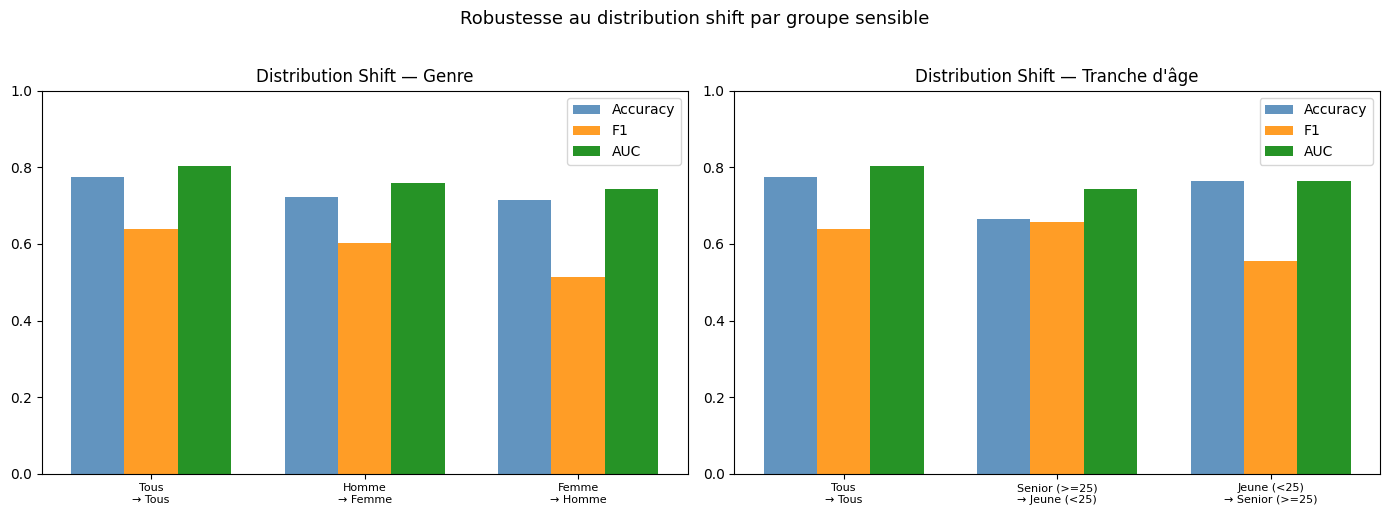

In [11]:
# Visualisation du distribution shift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_s, title in zip(
    axes,
    [df_shift_gender, df_shift_age],
    ["Distribution Shift — Genre", "Distribution Shift — Tranche d'âge"]
):
    labels = [f"{r['Entraîné sur']}\n→ {r['Évalué sur']}" for _, r in df_s.iterrows()]
    x = np.arange(len(df_s))
    width = 0.25
    ax.bar(x - width,   df_s["Accuracy"], width, label="Accuracy",  color="steelblue",  alpha=0.85)
    ax.bar(x,           df_s["F1"],       width, label="F1",         color="darkorange", alpha=0.85)
    ax.bar(x + width,   df_s["AUC"],      width, label="AUC",        color="green",      alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()

plt.suptitle("Robustesse au distribution shift par groupe sensible", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Synthèse : Tableau comparatif des 3 perturbations

=== SYNTHÈSE — Impact des perturbations ===
                    Perturbation    AUC     F1   Δ AUC    Δ F1
               Aucune (baseline) 0.8042 0.6400  0.0000  0.0000
           Bruit gaussien σ=0.25 0.7589 0.5333 -0.0452 -0.1067
            Bruit gaussien σ=0.5 0.7590 0.5000 -0.0451 -0.1400
            Bruit gaussien σ=1.0 0.7755 0.6034 -0.0287 -0.0366
          Valeurs manquantes 10% 0.7783 0.6299 -0.0258 -0.0101
          Valeurs manquantes 30% 0.7699 0.5854 -0.0343 -0.0546
          Valeurs manquantes 50% 0.7577 0.5124 -0.0464 -0.1276
Distribution shift Homme → Femme 0.7598 0.6019 -0.0444 -0.0381


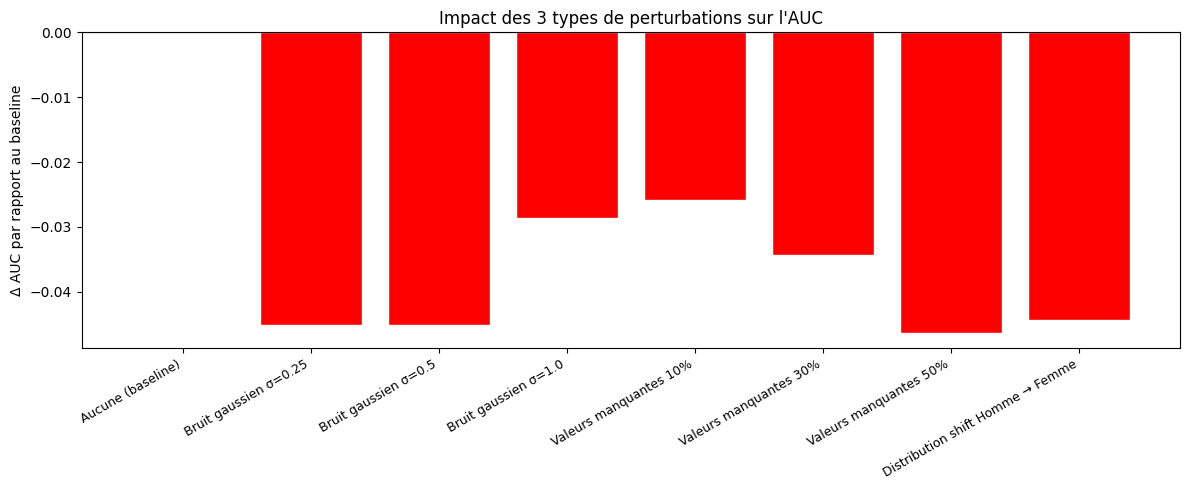

In [12]:
# Récapitulatif des dégradations d'AUC pour les 3 perturbations
summary_rows = [
    {"Perturbation": "Aucune (baseline)",
     "Paramètre": "-", "AUC": baseline_auc, "F1": baseline_f1},
]

# Bruit gaussien
for _, row in df_noise.iterrows():
    if row["sigma"] in [0.25, 0.5, 1.0]:
        summary_rows.append({
            "Perturbation": f"Bruit gaussien σ={row['sigma']}",
            "Paramètre": f"σ={row['sigma']}",
            "AUC": row["AUC"], "F1": row["F1"]
        })

# Valeurs manquantes
for _, row in df_missing.iterrows():
    if row["Taux manquant"] in [0.10, 0.30, 0.50]:
        summary_rows.append({
            "Perturbation": f"Valeurs manquantes {row['Taux manquant']:.0%}",
            "Paramètre": f"{row['Taux manquant']:.0%} manquant",
            "AUC": row["AUC"], "F1": row["F1"]
        })

# Distribution shift (hommes → femmes)
row_shift = df_shift_gender[df_shift_gender["Entraîné sur"] == "Homme"].iloc[0]
summary_rows.append({
    "Perturbation": "Distribution shift Homme → Femme",
    "Paramètre": "Cross-genre",
    "AUC": row_shift["AUC"], "F1": row_shift["F1"]
})

df_summary = pd.DataFrame(summary_rows)
df_summary["Δ AUC"] = (df_summary["AUC"] - baseline_auc).round(4)
df_summary["Δ F1"]  = (df_summary["F1"]  - baseline_f1).round(4)

print("=== SYNTHÈSE — Impact des perturbations ===")
print(df_summary[["Perturbation", "AUC", "F1", "Δ AUC", "Δ F1"]].round(4).to_string(index=False))

# Graphique de synthèse
plt.figure(figsize=(12, 5))
colors = ["green" if d >= 0 else "red" for d in df_summary["Δ AUC"]]
plt.bar(range(len(df_summary)), df_summary["Δ AUC"], color=colors, edgecolor="white")
plt.xticks(range(len(df_summary)), df_summary["Perturbation"], rotation=30, ha="right", fontsize=9)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Δ AUC par rapport au baseline")
plt.title("Impact des 3 types de perturbations sur l'AUC")
plt.tight_layout()
plt.show()

## 8. Analyse des résultats

### Robustesse au bruit gaussien
- L'AUC passe de 0.804 (baseline) à 0.716 à σ=2.0, soit une chute de 11 %. Le F1 descend de 0.64 à 0.50 dès σ=0.5. XGBoost absorbe bien les perturbations faibles (σ < 0.25) grâce aux seuils de splits des arbres, mais la dégradation s'accélère au-delà.
- Par feature, les plus fragiles sont `residence_since` (ΔAUC = −0.011), `duration` (−0.008) et `credit_amount` (−0.006). Ce sont des features financières, ce qui est cohérent avec leur importance SHAP élevée (Tâche 3). En revanche, `age` gagne paradoxalement en AUC quand on le perturbe (+0.011), ce qui suggère que le modèle surapprend légèrement sur cette feature.

### Robustesse aux valeurs manquantes
- L'imputation par médiane préserve bien les performances jusqu'à ~20 % de données manquantes (AUC = 0.768, contre 0.804 baseline). Au-delà de 30 %, la dégradation s'accélère (AUC = 0.758 à 50 %). Le F1 chute de 0.64 à 0.51 à 50 % de manquants.
- La médiane est une stratégie d'imputation simple qui ne capture pas les distributions conditionnelles, d'où la perte de signal au-delà de 30 %.

### Distribution shift et lien avec l'équité
- Entraîné sur les hommes et testé sur les femmes, l'AUC chute de 0.804 à 0.760 et le F1 de 0.64 à 0.60. Dans l'autre sens (femmes vers hommes), la chute est plus forte : AUC = 0.743, F1 = 0.51. Le modèle entraîné sur le groupe minoritaire (310 femmes) se généralise moins bien que celui entraîné sur le groupe majoritaire (690 hommes).
- Pour l'âge, la dégradation est similaire : seniors vers jeunes donne AUC = 0.744, jeunes vers seniors donne AUC = 0.765. Le modèle entraîné sur 149 jeunes uniquement performe mieux sur les 851 seniors qu'inversement, ce qui suggère que les jeunes forment un sous-groupe plus spécifique.
- Ces résultats confirment que les groupes démographiques ont des distributions différentes dans les features prédictives. C'est le mécanisme sous-jacent des disparités mesurées en Tâche 2 : le modèle apprend des patterns propres au groupe majoritaire qui se généralisent mal aux groupes minoritaires, validant la nécessité des corrections d'équité.